READ ANALYSIS XLSX

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
%matplotlib inline
os.getcwd()
file = '../Scenario_Analysis_NEWEST.xlsx'
df = pd.read_excel(file, sheet_name='CO2Duals')
df = df.loc[:, ~df.columns.str.contains(r'\.\d+$')]
df = df.set_index(df.columns[0])
hours = df.index
start_date = pd.Timestamp("2019-01-01 00:00")
dt_index = start_date + pd.to_timedelta(hours-1, unit="h")
df.index = dt_index
df.index.name = "datetime"
df.index.freq = 'h'


PLOT HOURLY DUALS ALONG THEIR MOVING AVERAGE

In [91]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import NullLocator
import matplotlib.colors as mc
import colorsys

# helper function: darken a color nicely
def darken(color, amount=0.55):
    try:
        c = mc.cnames[color]
    except:
        c = color
    h, l, s = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(h, max(0, min(1, l * amount)), s)


def plot_scenarios(df, scenarios, scenario_colors, start=None, end=None, ma_window=168):

    data = df[scenarios]
    if start or end:
        data = data.loc[start:end]

    fig, ax = plt.subplots(figsize=(14, 5))

    for scen in scenarios:
        base_color = scenario_colors[scen]
        ma_color = darken(base_color, 0.8)

        # Hourly line (faint)
        ax.plot(
            data.index,
            data[scen],
            color=base_color,
            alpha=0.25,
            label=scen
        )

        # Weekly moving average (bold)
        ma = data[scen].rolling(window=ma_window, min_periods=1).mean()
        ax.plot(
            data.index,
            ma,
            color=ma_color,
            label=f"{ma_window}h MA ({scen})"
        )

    ax.set_xlabel("")
    ax.set_ylabel("CO₂ Dual (EUR/t)")
    ax.set_title("Hourly CO₂ Dual (EUR/t)")
    # after you compute `data`
    first = data.index.min().normalize().replace(day=1)
    last = data.index.max()
    last_month_start = last.normalize().replace(day=1)
    next_month_start = last_month_start + pd.offsets.MonthBegin(1)

    ax.set_xlim(first, next_month_start)
    ax.margins(x=0)  # still no extra padding beyond these limits
    ax.margins(x=0)

    # Monthly ticks
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_minor_locator(NullLocator())

    ax.set_ylim(0, 120)

    ax.grid(axis='y', alpha=0.4)
    ax.set_axisbelow(True)

    
    # Legend below
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=len(scenarios) * 2,
        frameon=False,
    )

    fig.tight_layout()
    plt.show()


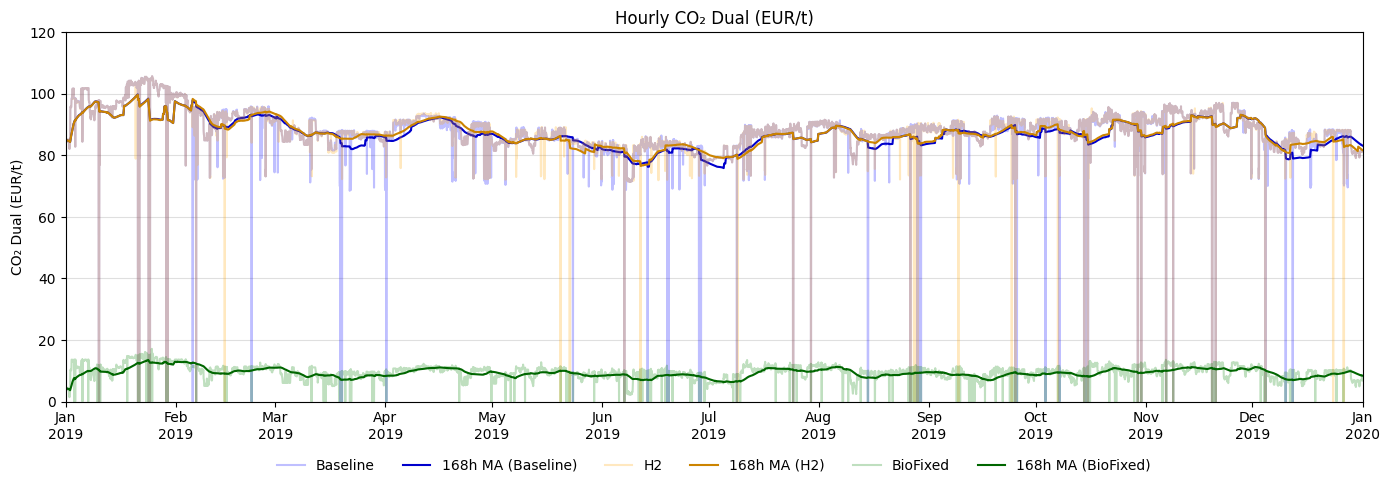

In [92]:
# all_colors 
# aqua, cyan, turquoise, teal, green, lime, forestgreen, chartreuse,
# blue, royalblue, deepskyblue, dodgerblue, skyblue, cornflowerblue,
# red, firebrick, crimson, orange, darkorange, gold, purple, indigo, magenta,
# brown, sienna, chocolate, gray, dimgray, slategray, black, white, lavenderblush

scenario_colors = {
    "Baseline":     "blue",
    "H2":           "orange", 
    "BioFixed":     "green",
    "CO2Trans":     "gray",
}

start="2019-03-01"
end="2019-06-30"

plot_scenarios(df, ["Baseline", "H2", "BioFixed"], scenario_colors)


PLOTTING ONLY MOVING AVERAGES (MAs)

In [93]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import NullLocator

def plot_ma_scenarios(df, scenarios, scenario_colors=None,
                      start=None, end=None, ma_window=168, min_per=1):
    """
    Plot only moving-average (MA) trends for selected scenarios.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with datetime index and scenario columns.
    scenarios : list of str
        Column names (scenarios) to plot.
    scenario_colors : dict, optional
        Mapping {scenario_name: color_string}, e.g.
        {"Baseline": "royalblue", "BioFixed": "turquoise"}.
        If a scenario is not in the dict, Matplotlib's default color cycle is used.
    start, end : str or Timestamp, optional
        Optional time window, e.g. '2019-03-01', '2019-06-30'.
    ma_window : int
        Moving average window in hours (e.g. 168 = 1 week).
    min_per : int
        min_periods argument for rolling().
    """

    if scenario_colors is None:
        scenario_colors = {}

    data = df[scenarios]
    if start or end:
        data = data.loc[start:end]

    fig, ax = plt.subplots(figsize=(14, 5))

    for scen in scenarios:
        ma = data[scen].rolling(window=ma_window, min_periods=min_per).mean()

        color = scenario_colors.get(scen, None)  # None → default color cycle

        ax.plot(
            data.index,
            ma,
            linestyle="-",
            linewidth=2,
            label=f"{ma_window}h MA ({scen})",
            color=color,
        )

    ax.set_xlabel("")
    ax.set_ylabel("CO₂ Dual (EUR/t)")
    ax.set_title(f"{ma_window}-hour Moving Average CO₂ Dual")

    # --- Month-aligned x-limits (so you get Jan 2020 when plotting full 2019) ---
    first_month_start = data.index.min().normalize().replace(day=1)
    last_month_start = data.index.max().normalize().replace(day=1)
    next_month_start = last_month_start + pd.offsets.MonthBegin(1)

    ax.set_xlim(first_month_start, next_month_start)
    ax.margins(x=0)

    # Monthly ticks only
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))
    ax.xaxis.set_minor_locator(NullLocator())

    ax.grid(axis='y', alpha=0.4)
    ax.set_axisbelow(True)


    # Legend below
    legend = ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.12),
        ncol=len(scenarios),
        frameon=False
    )
    for line in legend.get_lines():
        line.set_linewidth(3)

    fig.tight_layout()
    plt.show()


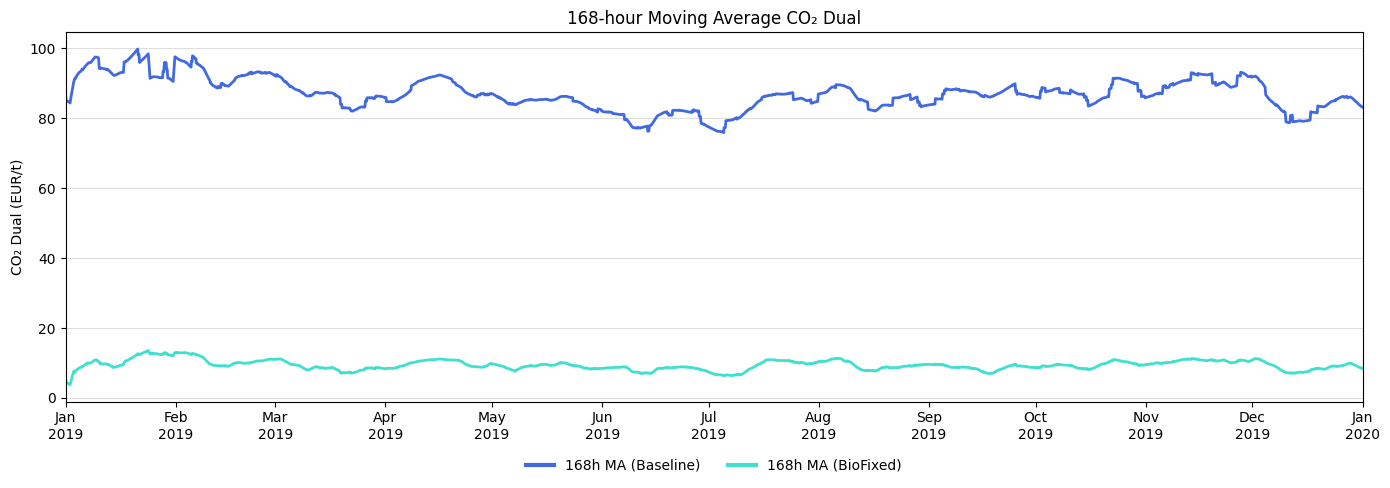

In [94]:
scenario_colors = {
    "Baseline": "royalblue",
    "BioFixed": "turquoise",
    "H2":       "green",
    "CO2Trans": "red",
}

start="2019-03-01"
end="2019-06-30"

plot_ma_scenarios(
    df,
    ["Baseline", "BioFixed"],
    scenario_colors=scenario_colors,
    ma_window=168,
)


AVERAGE CO2 DUAL VALUE

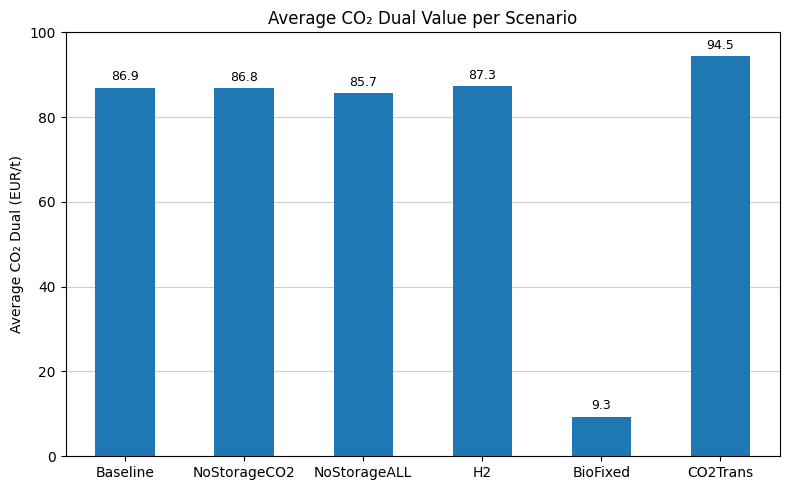

In [104]:
import matplotlib.pyplot as plt

scenario_means = df.mean()

fig, ax = plt.subplots(figsize=(8,5))

scenario_means.plot(kind='bar', ax=ax)

ax.set_ylabel("Average CO₂ Dual (EUR/t)")
ax.set_title("Average CO₂ Dual Value per Scenario")

# Grid behind bars
ax.grid(axis='y', alpha=0.6)
ax.set_axisbelow(True)

# X and Y ticks
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.set_yticks(range(0, 110, 20))

for i, value in enumerate(scenario_means):
    ax.text(
        i,                         # x-position
        value+1,                # y-position slightly above bar
        f"{value:.1f}",           # formatted label
        ha='center', va='bottom', fontsize=9
    )

plt.tight_layout()
plt.show()
